
# <span style="color:rgb(213,80,0)">Plantilla examen de robótica</span>

### Definición de funciones

En el análisis para el manipulador SCARA, es fundamental establecer una estrategia de segmentación basada de su cadena cinemática que permita un manejo preciso de cada componente. Esta metodología requiere la asignación de sistemas de referencia locales situados en cada centro de articulación rotacional, los cuales deben alinearse con la orientación del eslabón correspondiente. Al estructurar el robot de esta manera, se simplifica considerablemente el seguimiento del movimiento y la orientación del punto de interés P, que representa el extremo donde se sitúa la herramienta y cuya trayectoria es el objetivo primordial del control cinemático.


Aunque cada eslabón se describe inicialmente de forma aislada para facilitar el planteamiento físico, es imperativo unificar estas descripciones bajo un estándar común. Esto se debe a que las magnitudes físicas, tales como la velocidad o el torque, solo pueden ser operadas y validadas cuando se encuentran expresadas en un mismo plano de referencia. Por tal motivo, se define un Sistema de Referencia General o Inercial que actúa como el origen maestro desde el cual se transforman y coordinan todas las propiedades cinemáticas y dinámicas de la cadena, permitiendo que el sistema sea descrito como un conjunto coherente y sin restricciones operativas entre sus partes.


Bajo estas consideraciones, que permiten describir de manera simplificada cada cuerpo desde su propio sistema de referencia y posteriormente integrar todas las descripciones en un marco común, resulta necesario introducir la función de transformación homogénea general, $T_{i,j}$, Esta se expresa como una función matricial que depende de seis parámetros: tres asociados a la posición $x_{i,j} ,y_{i,j} ,z_{i,j}$, y tres ángulos de orientación, de un giro respecto al eje $\hat{x}$, $b_{i,j}$ de un giro respecto al eje $\hat{y}$ y $a_{i,j}$ respecto a un giro respecto al eje $\hat{z}$. Además, la transformación incluye un vector de perspectiva $\left\lbrack 0\;0\;0\right\rbrack$, y un factor de escala $\left\lbrack 1\right\rbrack$, los cuales completan la estructura de la matriz y permiten que esta sea cuadrada e invertible. La finalidad principal de esta formulación es facilitar la conversión entre distintos sistemas de referencia; es decir, mediante los elementos de esta matriz, bajo un sistema de referencia $j$ expresada en un sistema de referencia a otra equivalente en un sistema de referencia $i$.


El código de MATLAB implementa la función de Transformación Homogénea General como el operador matemático principal para facilitar la transición entre los diversos marcos de referencia. Esta función matricial de integra parámetros esenciales, incluyendo distancias de posición y ángulos de orientación asociados a los giros sobre los ejes principales. Al componerse de una submatriz de rotación y un vector de posición, la matriz resultante permite realizar un mapeo de coordenadas efectivo, logrando que cualquier descripción realizada en un sistema móvil pueda ser interpretada con total exactitud desde la perspectiva del sistema inercial, lo cual constituye la base técnica para el desarrollo de los modelos de postura y velocidad del robot.


In [1]:
%Deficición de la función de manera símbolica
syms Tij(x_i_j,y_i_j,z_i_j,gi_j,bi_j,ai_j) P_i_j
%Definición de la transformación homogénea general
Tij(x_i_j,y_i_j,z_i_j,gi_j,bi_j,ai_j) = [cos(ai_j)*cos(bi_j) cos(ai_j)*sin(bi_j)*sin(gi_j)-sin(ai_j)*cos(gi_j) sin(ai_j)*sin(gi_j)+cos(ai_j)*sin(bi_j)*cos(gi_j) x_i_j; sin(ai_j)*cos(bi_j) cos(ai_j)*cos(gi_j)+sin(ai_j)*sin(bi_j)*sin(gi_j) sin(ai_j)*sin(bi_j)*cos(gi_j)-cos(ai_j)*sin(gi_j) y_i_j; -sin(bi_j) cos(bi_j)*sin(gi_j) cos(bi_j)*cos(gi_j) z_i_j; 0 0 0 1]


La matriz de rotación $R_{i,j}$, se compone de las primeras tres filas y columnas de la transformación homogénea y define la relación de orientación entre los sistemas involucrados. Utilizando funciones de seno y coseno sobre los ángulos de giro, esta submatriz permite proyectar la actitud de un eslabón $j$ desde la perspectiva de un sistema de referencia $i$. Su implementación es fundamental para describir cómo cambia la orientación del robot SCARA a lo largo de su cadena cinemática.


In [2]:
R_i_j=[cos(ai_j)*cos(bi_j) cos(ai_j)*sin(bi_j)*sin(gi_j)-sin(ai_j)*cos(gi_j) sin(ai_j)*sin(gi_j)+cos(ai_j)*sin(bi_j)*cos(gi_j); sin(ai_j)*cos(bi_j) cos(ai_j)*cos(gi_j)+sin(ai_j)*sin(bi_j)*sin(gi_j) sin(ai_j)*sin(bi_j)*cos(gi_j)-cos(ai_j)*sin(gi_j); -sin(bi_j) cos(bi_j)*sin(gi_j) cos(bi_j)*cos(gi_j)]


La matriz de rotación $R_{i,j}$, extrae la submatriz de $3\cdot 3$ de la transformación homogénea para definir exclusivamente la relación de orientación entre los sistemas involucrados. Mediante el uso de funciones trigonométricas sobre los ángulos de giro, este componente permite proyectar la actitud de un eslabón $j$, desde la perspectiva de un sistema de referencia $i$. Su implementación es fundamental para describir cómo cambia la orientación del robot SCARA a lo largo de su cadena cinemática sin considerar los desplazamientos lineales.


In [3]:
P_i_j=[x_i_j;y_i_j;z_i_j]


El vector de posición $P_{i,j}$, extrae la información de la última columna de la matriz de transformación para indicar las coordenadas espaciales $\left(x,y,z\right)$ de un sistema $j$ visto desde un sistema $i$. Esta herramienta es fundamental para cuantificar el desplazamiento entre los eslabones del robot SCARA, permitiendo que cualquier punto definido localmente sea mapeado con exactitud en el espacio tridimensional dentro de un marco de referencia unificado.

## Modelado del robot Scara

<p style="text-align:left">
   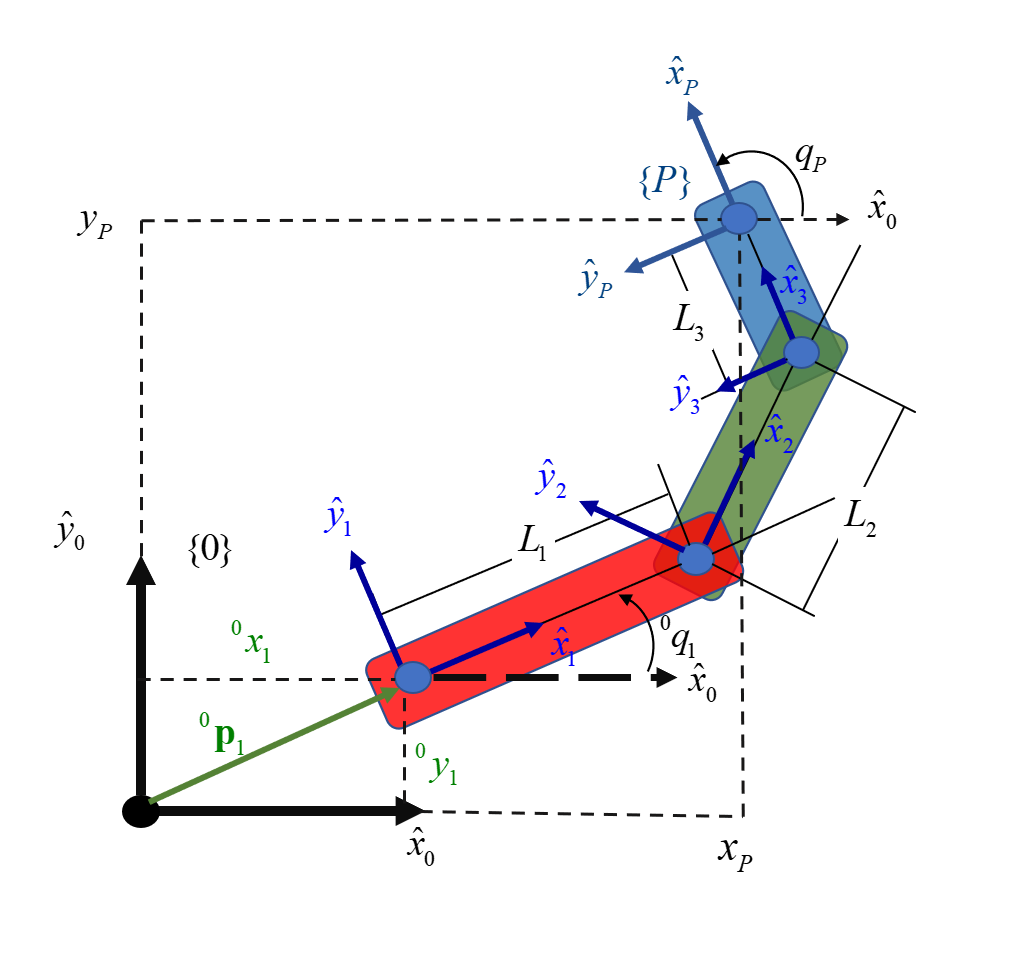
</p>

### Planteamiento del modelo cinemático directo de la posición

El estudio cinemático del manipulador SCARA se basa en la representación de su estructura como una cadena de eslabones rígidos conectados por articulaciones, lo que permite proyectar su movimiento sobre un plano de trabajo específico. Para este análisis, se han establecido marcos de referencia locales en cada centro de rotación que facilitan el seguimiento de la orientación y posición de los componentes de acuerdo a sus dimensiones físicas. Esta configuración es esencial para determinar cómo las variables articulares afectan la ubicación final del punto de interés P, asegurando que el diseño cumpla con el volumen de operación y las tareas de precisión requeridas.


El modelo cinemático directo se define como el proceso analítico para determinar la postura del efector final a partir de los ángulos conocidos de las juntas del robot. La implementación de este modelo requiere la construcción de una jerarquía de bases, desde la base inercial {O}, hasta el sistema del punto final {P}, permitiendo unificar la descripción de toda la cadena cinemática. Mediante el uso de transformaciones homogéneas que integran traslaciones y giros, el sistema logra calcular con exactitud el espacio alcanzable por el robot, proporcionando la base matemática necesaria para la posterior programación de movimientos y trayectorias operativas.


In [4]:
syms x_O_1 y_O_1 theta_O_1 L_2 theta_1_2 L_3 theta_2_3 L_1

T_O_1 = Tij(x_O_1,y_O_1,0,0,0,theta_O_1)


La transformación del sistema inicial {1} respecto a la base inercial {O} se establece mediante una matriz que integra el desplazamiento en el plano y la rotación inicial de la cadena. Una ventaja fundamental de las matrices de transformación homogénea es su propiedad de composición, la cual permite determinar la postura de un sistema final {n} respecto a la base mediante el producto sucesivo de transformaciones intermedias entre eslabones. Esta característica simplifica el análisis cinemático del robot SCARA al permitir la multiplicación de matrices individuales, como $T_{0,1}$, $T_{1,2}$, $T_{2,3}$ y $T_{3,p}$, para obtener una descripción única y completa de la posición y orientación del punto final {P} sin depender de sistemas de referencia relativos que cambian constantemente durante el movimiento del manipulador.


Las transformaciones intermedias entre los eslabones del robot SCARA se definen mediante matrices que consideran las longitudes físicas L y los ángulos de rotación de cada junta. El sistema $T_{1,2}$ representa una traslación sobre el eje horizontal de magnitud $L_1$ junto con un giro ${\theta \;}_{0,1}$.


In [5]:
T_1_2 = Tij(L_1,0,0,0,0,theta_1_2)


Mientras que $T_{2,3}$ replica este comportamiento para el siguiente segmento de la cadena considerando la longitud $L_2$ y el ángulo ${\theta \;}_{2,3}$.


In [6]:
T_2_3 = Tij(L_2,0,0,0,0,theta_2_3)


Por último la relación $T_{3,p}$ se describe únicamente como una traslación de magnitud $L_3$ sin cambio de orientación, debido a que el sistema final del efector y el sistema del tercer eslabón se encuentran montados sobre el mismo cuerpo rígido. Estas definiciones matriciales permiten estructurar la geometría del brazo de forma modular, facilitando el cálculo de la postura total del manipulador a través de la multiplicación sucesiva de cada una de estas etapas.


In [7]:
T_3_P = Tij(L_3,0,0,0,0,0)


La matriz de transformación total $T_{O,P}$ , se obtiene mediante el producto simplificado de todas las matrices intermedias de la cadena cinemática, consolidando la relación entre el efector final y la base inercial. Este arreglo matricial resultante sintetiza la geometría compleja del robot SCARA en una sola expresión que depende exclusivamente de la configuración interna de las juntas rotacionales. Aunque la matriz contiene toda la información del sistema, su valor principal reside en los componentes que describen la posición y orientación del punto final P, permitiendo interpretar cómo se posiciona el manipulador en el espacio de trabajo de acuerdo con los ángulos aplicados en cada articulación. De esta manera, el uso de funciones de simplificación en MATLAB facilita la obtención de un modelo directo coherente que sirve como base fundamental para el seguimiento de trayectorias y el control de la postura del robot.


In [8]:
T_O_P = simplify(T_O_1*T_1_2*T_2_3*T_3_P)

#### Vector de postura del robot

El vector de postura del robot $\xi {\;}_{O,P}$ representa la síntesis de la ubicación y orientación del efector final en el espacio de trabajo. Aunque en una descripción general de seis grados de libertad se consideran tres coordenadas de posición y tres de orientación, el análisis del robot SCARA se simplifica al operar predominantemente en el plano X Y. Debido a esta restricción geométrica, la coordenada en Z y las rotaciones fuera del plano horizontal se consideran nulas o irrelevantes para el control de la tarea, permitiendo reducir el vector a un arreglo de tres parámetros esenciales.


$$\xi {\;}_{O,P} =\left\lbrack \begin{array}{c} P_{O,P} \newline \theta {\;}_{O,P}  \end{array}\right\rbrack =\left\lbrack \begin{array}{c} x_{O,P} \newline y_{O,P} \newline z_{O,P} \newline \phi {\;}_{O,P} \newline \psi {\;}_{O,P} \newline \theta {\;}_{O,P}  \end{array}\right\rbrack$$

El vector de postura del punto final de la cadena cinématica quedará definido como:


$$\xi {\;}_{O,P} =\left\lbrack \begin{array}{c} x_{O,P} \newline y_{O,P} \newline \theta {\;}_{O,P}  \end{array}\right\rbrack$$

La extracción de este vector se realiza directamente desde la matriz de transformación homogénea total, donde las coordenadas de posición x y y corresponden a los elementos superiores de la última columna. Por otro lado, la orientación final del punto P se deduce mediante la suma algebraica de los ángulos de cada articulación rotacional que compone la cadena cinemática. Esta relación matemática permite establecer una correspondencia directa entre la configuración interna del vector de juntas q y la postura resultante en el espacio cartesiano, cumpliendo con el objetivo primordial del modelo cinemático directo de las posiciones.


In [9]:
xi_O_P = [T_O_P(1,4);T_O_P(2,4);theta_O_1+theta_1_2+theta_2_3]


La postura final del robot, representada por el vector $\xi {\;}_{O,P}$, se define matemáticamente en función del vector de configuración q, el cual agrupa los ángulos de cada una de las juntas rotacionales del manipulador. Esta relación constituye el núcleo del modelo cinemático directo de las posiciones, permitiendo mapear cómo los giros individuales en la base y los eslabones se traducen en coordenadas cartesianas específicas y en una orientación total para el punto final P. Al consolidar esta expresión, el sistema adquiere la capacidad de predecir con exactitud la ubicación del efector en el espacio de trabajo basándose únicamente en el estado interno de sus actuadores.

### Planteamiento del modelo cinématico inverso de las posiciones

El modelo cinemático inverso aborda el reto de encontrar los parámetros articulares necesarios para alcanzar una postura objetivo definida de forma independiente al estado actual del robot. A diferencia del modelo directo, en este planteamiento se establece un vector de pose deseada con valores propios de posición y orientación que funcionan como la meta del movimiento. El objetivo principal es determinar analíticamente el vector de configuración de las juntas que satisfaga esta postura, permitiendo que el manipulador traduzca coordenadas de destino en el espacio de trabajo hacia los comandos específicos que cada actuador debe ejecutar, este modelo debe encontrar los parámetros de  $q={\left\lbrack \begin{array}{ccc} \theta {\;}_{O,1}  & \theta {\;}_{1,2}  & \theta {\;}_{2,3}  \end{array}\right\rbrack }^T$ para la configuración de pose establecida.


In [10]:
syms x_O_P y_O_P theta_O_P
xi_O_P = [x_O_P; y_O_P; theta_O_P]


Debido a la complejidad de las ecuaciones no lineales, se utiliza la técnica de desacoplamiento para simplificar la cadena cinemática del robot SCARA. Este proceso consiste en determinar la posición de un punto intermedio, denominado $P{\;}_{O,3}$, el cual se sitúa en la articulación que conecta el segundo y tercer eslabón. Al proyectar la ubicación del punto final P hacia atrás mediante relaciones trigonométricas que consideran la longitud $L_3$ y el ángulo de orientación deseado $\theta {\;}_{O,P}$, es posible calcular las coordenadas locales $x{\;}_{O,3}$ e $y{\;}_{O,3}$. Esta reducción geométrica transforma el problema global en un análisis de dos eslabones, facilitando la deducción de los ángulos de las juntas mediante el uso de la ley de los cosenos y otras herramientas matemáticas fundamentales.


In [11]:
x_O_3 = x_O_P-L_3*cos(theta_O_P)

In [12]:
y_O_3 = y_O_P-L_3*sin(theta_O_P)


Por teorema de Pitágoras, se establece el valor de $r$.


In [13]:
r = sqrt((x_O_3)^2+(y_O_3)^2)


Una vez obtenidas las coordenadas del punto intermedio, se aplica el teorema de Pitágoras para determinar la magnitud del vector de posición r, el cual representa la distancia desde la base hasta la articulación del tercer eslabón. Esta longitud r forma parte de un triángulo oblicuo constituido por los dos primeros eslabones del robot SCARA, permitiendo el uso de la ley de cosenos para establecer una relación entre las dimensiones físicas L1 y L2 con la configuración angular requerida.


Mediante la manipulación de las propiedades trigonométricas, específicamente el uso del ángulo complementario $\psi$, se logra despejar el coseno del ángulo $\theta {\;}_{1,2}$. Este procedimiento es un paso crítico en la cinemática inversa, ya que transforma la información espacial del brazo en una expresión analítica que depende exclusivamente de las longitudes de los eslabones y la posición deseada del efector final, facilitando el cálculo posterior de los ángulos articulares mediante la función arcocoseno.


In [14]:
cos_theta_1_2=((r^2)-(L_1^2)-(L_2^2))/(2*L_1*L_2)


De la entidad pitágorica $\sin^2 \theta +\cos^2 \theta =1$ y de la definción anterior, podemos encontrar el valor del seno de $\theta {\;}_{1,2}$:


In [15]:
sin_theta_1_2=sqrt(1-(cos_theta_1_2))


A partir de la identidad pitagórica, el script calcula el valor del seno de $\theta {\;}_{1,2}$  para complementar la información del coseno obtenida en el paso anterior. Este procedimiento es fundamental para asegurar que la solución del ángulo sea consistente con la geometría del brazo, permitiendo que el modelo matemático maneje correctamente los signos y las magnitudes de la deflexión entre el primer y segundo eslabón del robot SCARA.


In [16]:
theta_1_2 = atan2(sin_theta_1_2,cos_theta_1_2)


Gracias a las definiciones de seno y coseno, se obtiene el valor numérico del ángulo $\theta {\;}_{1,2}$ a través de la función atan2. El uso de esta función es crítico en la cinemática inversa, ya que considera el cuadrante de las coordenadas de trabajo y brinda un resultado válido y unívoco para el modelo. Esto permite que el sistema determine con precisión la orientación relativa necesaria entre las juntas para posicionar el efector en el punto de destino. De la imagen, sabemos que $\theta {\;}_{0,1} =\gamma -\beta \;$, que $\gamma =\textrm{atan}\left(\frac{y_{O,3} }{x_{O,3} }\right)$ y que $\beta \;$ se puede obtener a partir de la creación de un nuevo triángulo rectángulo, de hipotenusa $r$ y de catetos $L_1 +L_2 \cdot \cos \left(\theta {\;}_{1,2} \right)\;y\;L_2 \cdot \sin \left(\theta {\;}_{1,2} \right)$, tal que el valor de $\beta \;=\textrm{atan}\left(\frac{L_2 \cdot \sin \left(\theta {\;}_{1,2} \right)}{L_1 +L_2 \cdot \cos \left(\theta {\;}_{1,2} \right)}\right)$. Realizando los correspondientes cálculos y sustituciones, se obtiene:


In [17]:
beta=atan2(L_2*sin_theta_1_2,L_1+L_2*cos_theta_1_2)

In [18]:
gamma = atan2(y_O_3,x_O_3)

In [19]:
theta_O_1=gamma-beta


El cálculo del tercer ángulo articular se simplifica al considerar la relación de la orientación total deseada $\theta {\;}_{0,P}$ respecto a los giros de los eslabones anteriores. Debido a que el ángulo total es el resultado de la suma algebraica de todas las juntas rotacionales de la cadena cinemática, el valor de $\theta {\;}_{2,3}$ se obtiene despejando los valores ya conocidos de $\theta {\;}_{0,1}$ y $\theta {\;}_{1,2}$ de la expresión general. Este procedimiento analítico permite cerrar el modelo inverso garantizando que la postura final del efector no solo coincida en posición cartesiana, sino que también cumpla con la orientación específica requerida por la tarea.


In [20]:
theta_2_3=theta_O_P-theta_O_1-theta_1_2


Una vez obtenidos los ángulos que componen la cadena cinemática en función de los parámetros de pose deseados, se procede a definir el vector de configuración q. Este vector agrupa de forma ordenada los valores de $\theta {\;}_{0,1}$, $\theta {\;}_{1,2}$ y $\theta {\;}_{2,3}$ , constituyendo la solución final del modelo cinemático inverso de las posiciones. Al consolidar esta información, el sistema adquiere la capacidad de traducir una coordenada objetivo en el espacio de trabajo hacia las consignas articulares exactas, permitiendo que el robot SCARA ejecute movimientos precisos y autónomos basados en la configuración de sus actuadores.


In [21]:
q=[theta_O_1;theta_1_2;theta_2_3]


Con la obtención del vector de configuración q, se concluye el modelado cinemático inverso del robot SCARA. Este modelo resulta indispensable para simplificar el control de los movimientos y posturas, permitiendo que el sistema determine de manera autónoma cómo articularse para alcanzar una pose final específica. Al optimizar los desplazamientos y facilitar la planeación de trayectorias, esta herramienta matemática garantiza que el manipulador opere con precisión dentro de su volumen de trabajo, traduciendo coordenadas cartesianas en los estados angulares que cada motor debe adoptar.


El proceso de resolución evidencia el alto costo computacional y la complejidad matemática derivada de la naturaleza no lineal de las ecuaciones. Es importante destacar que, debido a estas condiciones, pueden existir soluciones múltiples para llegar a un mismo punto, lo que implica que el robot podría adoptar diferentes configuraciones para una misma postura. Asimismo, este análisis permite identificar puntos críticos donde se podrían perder grados de libertad, lo que influye directamente en el control de las velocidades y establece la base para el estudio dinámico que se presentará en las secciones posteriores del reporte.

### Modelo cinemático directo de las velocidades

A partir del modelo cinemático de posición, se define la matriz Jacobiana del robot como la herramienta matemática fundamental para determinar la relación entre el movimiento de las articulaciones y la velocidad resultante en el punto final.


In [22]:
syms theta_dot_O_1 theta_dot_1_2 theta_dot_2_3 theta_O_1 theta_1_2 theta_2_3
xi_O_P = [T_O_P(1,4);T_O_P(2,4);theta_O_1+theta_1_2+theta_2_3]


Esta matriz se construye mediante las derivadas parciales del vector de postura respecto a cada variable del vector de configuración \$q\$, permitiendo cuantificar el efecto que la velocidad de cada motor tiene sobre la velocidad lineal y angular del efector. El cálculo del Jacobiano es esencial para evaluar la movilidad del robot SCARA, ya que su determinante ofrece una medida cuantitativa de la manipulabilidad y ayuda a identificar configuraciones singulares donde el sistema podría perder movilidad.


La matriz Jacobiana se obtiene mediante el comando jacobian, operando sobre el vector de postura $\xi {\;}_{O,P}$ en función de los ángulos articulares. La estructura resultante establece un puente analítico no solo para los modelos de velocidad y aceleración, sino también para relacionar las fuerzas exteriores aplicadas al robot con los torques necesarios en cada actuador. Mediante la simplificación de términos trigonométricos, se genera una matriz que sintetiza la dinámica diferencial del manipulador, proporcionando la base necesaria para implementar algoritmos de control precisos y analizar la capacidad de respuesta del robot ante cambios rápidos en su trayectoria.


Por definición, $J\left(\theta \;\right)=\left\lbrack \frac{\partial \;\xi {\;}_j \;}{\partial \;q_i }\right\rbrack$, por lo tanto, el jacobiano del robot SCARA analizado será:


In [23]:
J_theta = jacobian(xi_O_P,[theta_O_1, theta_1_2,theta_2_3])


La velocidad angular y lineal en el extremo del robot se determina mediante la relación entre la matriz Jacobiana y el vector de velocidades articulares. Al multiplicar la matriz J, que depende de la configuración actual del brazo, por las velocidades de giro de cada motor, se obtiene el vector de velocidad de la postura del robot. Esta operación matricial permite descomponer el movimiento resultante en dos componentes lineales para los ejes x e y, así como una velocidad angular total para el punto final P, proporcionando una descripción completa del comportamiento dinámico del manipulador desde la perspectiva del sistema inercial. A través de la siguiente expresión $\dot{\;\xi \;} {\;}_{O,P} =J\left(\theta \right)\times \dot{\;q}$, con $\dot{\;q} ={\left\lbrack \dot{\;\theta } {\;}_{O,1} \;\;\;\dot{\;\theta \;} {\;}_{1,2} \;\;\dot{\;\theta \;} {\;}_{2,3} \right\rbrack }^T$ podemos calcular la velocidad angular y lineal al final de la cadena cinemática, así como una velocidad angular total en el punto final {P}, elementos que componen al vector  $\dot{\;\xi \;} {\;}_{O,P} \;\left(q,\dot{\;q} \right)$. En este caso de interés, la matriz inversa del modleo es:


In [24]:
xi_dot_O_P=J_theta*[theta_dot_O_1;theta_dot_1_2;theta_dot_2_3]

### Modelo cinemático inverso de las velocidades

La matriz jacobiana es una matriz invertible de suma importancia que define al modelo inverso de las velocidades de un robot. El problema es el siguiente: se conoce un vector de velocidad que se debe cumplir para el movimiento de la cadena cinemática, pero se desconocen las velocidades angulares de cada junta rotacional de nuestro modelo SCARA. A diferencia del caso anterior, ahora es necesario determinar qué tán rápido o lento se debe accionar un motor en cada junta para lograr la velocidad deseada.


Del modelo cinemático directo de las velocidades, $\dot{\;\xi \;} {\;}_{O,P\;} =J\left(q\right)\dot{\;q}$, depenjando el vector derivado de la configuración del vector, $\dot{\;q} =J^{-1} \left(\theta \;\right)\dot{\;\xi \;} {\;}_{O,P}$.


La matriz jacobiana inversa es la clave que nos permite interpretar una velocidad deseada en el sistema {P} y que nos permite traducirlas a las velocidades angulares de cada junta rotacional. Es una pieza clave para establecer el control del movimento del robot y determinar si las velocidades propuestas son alcanzables. Un valor muy grande dentro de esta matriz indica que, para un leve movimiento de la cadena cinemática requiere en sí un gran trabajo o potencia en el actuador donde se muestra el resultado de gran magnitud. En este caso de interés, la matriz inversa del modleo es:


In [25]:
syms x_dot_O_P y_dot_O_P theta_dot_O_P
inv(J_theta)


Definiendo al vector de las velocidades deseadas para el punto P, $\dot{\;\xi \;} {\;}_{O,P}$:


In [26]:
xi_dot_O_P=[x_dot_O_P; y_dot_O_P; theta_dot_O_P]


De tal modo que la multiplicación de ambas matrices resulta en:


In [27]:
q_dot=J_theta\xi_dot_O_P


De este modo, se ha calculado al vector $\dot{\;q} ={\left\lbrack \begin{array}{ccc} \dot{\;\theta \;} {\;}_{O,1}  & \dot{\;\theta \;} {\;}_{1,2}  & \dot{\;\theta \;} {\;}_{2,3}  \end{array}\right\rbrack }^T$, donde el resultado mostrado arriba indica el valor que debe tomar cada velocidad angular de cada junta, respectivamente, para alcanzar las condiciones declaradas en el vector de velocidad $\dot{\;\xi \;} {\;}_{O,P}$, resolviendo efectivmamente el problema que este modelo planteaba. Cabe mencionar que, para este modelo, $q={\left\lbrack \begin{array}{ccc} \theta {\;}_{O,1}  & \theta {\;}_{1,2}  & \theta {\;}_{2,3}  \end{array}\right\rbrack }^T$ son de alguna forma valores ya conocidos, ya sea por el modelo directo o inverso de la cinemática de la posición del robot.

### Modelo cinemático directo de las aceleaciones

El modelo de aceleraciones se fundamenta en el uso de la matriz jacobiana, de igual forma que con las velocidades, incorporando ahora la definición de su derivada temporal. Conocer la variación de las proyecciones de las velocidades tangenciales y angulares es de suma relevancia, ya que permite definir cómo el movimiento de cada cuerpo dentro de la cadena cinemática afecta directamente a la aceleración del efector final. La matriz jacobiana derivada $\dot{J} \left(q,\dot{\;q} \right)=\frac{dJ\left(q\right)\;}{\;\textrm{dt}}=\frac{\partial \;J\left(q\right)\;}{\partial \;q_i }\dot{\;q\;} {\;}_i$ , sintetiza esta evolución temporal de la geometría del robot, permitiendo establecer una relación analítica entre el estado actual de movimiento y los cambios bruscos de velocidad en el espacio de trabajo.


El cálculo de la derivada de la jacobiana se realiza mediante la aplicación de la regla de la cadena, sumando las derivadas parciales de la matriz respecto a cada ángulo multiplicadas por sus respectivas velocidades angulares. El resultado mostrado, almacenado en la variable `J_dot`, integra las longitudes de los eslabones con las funciones trigonométricas de la configuración y las velocidades de las juntas. Esta matriz es un componente esencial para el modelo dinámico completo, ya que permite predecir las fuerzas inerciales y garantizar un control suave durante trayectorias que involucran arranques, frenados o cambios de dirección rápidos del robot SCARA.


In [28]:
syms theta_ddot_O_1 theta_ddot_1_2 theta_ddot_2_3
J_dot=diff(J_theta,theta_O_1)*theta_dot_O_1+diff(J_theta,theta_1_2)*theta_dot_1_2+diff(J_theta,theta_2_3)*theta_dot_2_3


Dentro del modelo de aceleración, se identifican componentes críticos conocidos como aceleraciones centrípetas y el efecto de Coriolis. Estas fuerzas surgen debido a la rotación simultánea de múltiples eslabones, donde el movimiento lineal de un segmento se ve alterado por la rotación previa de la base o de los eslabones intermedios. Definir correctamente estos efectos en el script es fundamental para el control dinámico, ya que permite predecir y compensar las variaciones en la trayectoria que no son causadas por una aceleración directa de los motores, sino por la inercia y la geometría rotacional del robot SCARA.


De los resultados del modelo dinámico directo de la velocidad del punto final P, $\dot{\;\xi \;} {\;}_{O,P} =J\left(\theta \;\right)\times {\left\lbrack \begin{array}{ccc} \dot{\;\theta \;} {\;}_{O,1}  & \dot{\;\theta \;} {\;}_{1,2}  & \dot{\;\theta \;} {\;}_{2,3}  \end{array}\right\rbrack }^T =J\left(\theta \;\right)\times \dot{\;q}$, al derivar y utilizar la regla de la cadena, obtendríamos $\ddot{\;\xi \;} {\;}_{O,P} =\dot{J} \left(q,\dot{\;q} \right)\times \dot{\;q} +J\left(q\right)\times \ddot{\;q}$. La expresión de aceleración del punto final describe la interacción conjunta entre el efecto directo de las aceleraciones angulares aplicadas en las juntas y las aceleraciones inherentes al movimiento de la cadena cinemática. Estas últimas surgen del desplazamiento relativo de cada eslabón y se componen principalmente de aceleraciones centrípetas y del efecto de Coriolis. Este fenómeno físico altera el movimiento lineal de un segmento debido a la rotación previa de los eslabones anteriores, generando términos no lineales que deben ser compensados para un control preciso. Gracias a la integración de estos componentes, es posible calcular analíticamente el vector de aceleración total en el efector del robot SCARA, a estas definiciones, se puede calcular el vector $\ddot{\;\xi } {\;}_{O,P}$:


In [29]:
xi_dot_O_P=J_theta*[theta_dot_O_1;theta_dot_1_2;theta_dot_2_3];
xi_ddot_O_P=J_theta*[theta_ddot_O_1;theta_ddot_1_2;theta_ddot_2_3]+J_dot*xi_dot_O_P


La obtención del vector de aceleración en el punto final se realiza mediante la combinación de la matriz Jacobiana y su derivada temporal. Esto se traduce en una expresión que suma el efecto de las aceleraciones angulares de las juntas con el producto de la matriz derivada por las velocidades actuales del sistema. Este resultado, almacenado en `xi_ddot_0_P`, proporciona una descripción completa de cómo el efector cambia su rapidez y dirección en cada instante del tiempo, integrando tanto los comandos directos de los motores como las fuerzas de inercia que aparecen de forma natural por la geometría del manipulador.


Así, se consiguen las expresiones de la postura $q={\left\lbrack \begin{array}{ccc} \theta {\;}_{O,1}  & \theta {\;}_{1,2}  & \theta {\;}_{2,3}  \end{array}\right\rbrack }^T$ y de las velocidades angulares de las juntas $\dot{\;q} ={\left\lbrack \begin{array}{ccc} \dot{\;\theta \;} {\;}_{O,1}  & \dot{\;\theta \;} {\;}_{1,2}  & \dot{\;\theta \;} {\;}_{2,3}  \end{array}\right\rbrack }^T$ que definen cómo se acelera tangencialmente y rotacionalmete el punto P cuando se traslada de una configuración antigua a otra nueva.

### Modelo cinemático inverso de las aceleraciones

Este modelo se encarga de determinar las aceleraciones angulares que cada una de las juntas del robot debe generar para que el efector final alcance una aceleración tangencial y angular específica en el plano de trabajo. A diferencia del modelo directo, aquí el punto de partida es un requerimiento de movimiento en el espacio cartesiano, definido por el vector $\ddot{\;\xi \;} {\;}_{O,P}$. El objetivo es encontrar la combinación exacta de cambios de velocidad en los motores que permita al manipulador seguir una trayectoria dinámica con total precisión, asegurando que el punto final P cumpla con las leyes de movimiento establecidas para la tarea.


In [30]:
syms x_ddot_O_P y_ddot_O_P theta_ddot_O_P
xi_ddot_O_P=[x_ddot_O_P;y_ddot_O_P; theta_ddot_O_P]


Para resolver la cinemática inversa de aceleraciones, se utiliza una expresión que relaciona la aceleración deseada en el extremo con la configuración actual del robot y sus velocidades presentes. Aunque teóricamente se podría derivar el modelo inverso de velocidades, la naturaleza no lineal de la matriz inversa genera complicaciones matemáticas que hacen inviable ese camino. En su lugar, se opta por una formulación que resta los efectos de las aceleraciones centrípetas y de Coriolis a la aceleración total requerida, aplicando después la influencia de la geometría del brazo. Del modelo directo de las aceleraciones para este robot SCARA, $\ddot{\;\xi \;} {\;}_{O,P} =\dot{J} \left(q,\dot{\;q} \right)\times \dot{\;q} +J\left(q\right)\times \ddot{\;q}$, y despejando $\ddot{\;q}$, se obtiene la expresión $\ddot{\;q} =J^{-1} \left(q\right)\times \left(\ddot{\;\xi \;} {\;}_{O,P} -\dot{J} \left(q,\dot{\;q} \right)\times \dot{\;q} \right)$. Ya que $\dot{\;q} =J^{-1} \left(\theta \;\right)\dot{\;\xi \;} {\;}_{O,P}$  la matriz inversa no es derivable y en realidad genera bastante complicaciones para ser calulada de esta forma, se opta por la primera definición presentada, tomando en cuenta que el vector $\dot{\;q} ={\left\lbrack \begin{array}{ccc} \dot{\;\theta \;} {\;}_{O,1}  & \dot{\;\theta \;} {\;}_{1,2}  & \dot{\;\theta \;} {\;}_{2,3}  \end{array}\right\rbrack }^T$ es un vector conocido. Así pues, se define el vector $\ddot{\;q}$, el cual define exactamente cómo debe variar la rapidez de cada actuador para vencer las inercias del sistema y alcanzar la postura final con la aceleración deseada.


In [31]:
q_ddot=simplify(J_theta\(xi_ddot_O_P-J_dot*q_dot))


El vector resultante q\_ddot representa el estado dinámico que debe adoptar cada actuador en su respectivo eslabón para materializar el movimiento deseado en el extremo del robot. Cada renglón de esta expresión analítica define la aceleración angular específica que un motor debe imprimir a su junta, considerando no solo el empuje necesario para avanzar, sino también las fuerzas inerciales y las restricciones geométricas de la cadena cinemática. Es el mapa final que traduce una intención de movimiento en el espacio de trabajo hacia comandos físicos reales para los motores del SCARA. Como se observa en el resultado, la expresión es considerablemente extensa debido a la naturaleza no lineal del manipulador. El cálculo final queda definido en función de la configuración de postura actual, la velocidad angular presente en cada junta y las aceleraciones tangenciales y angulares deseadas. Esta interdependencia muestra cómo cualquier cambio mínimo en la posición de un eslabón afecta drásticamente el esfuerzo requerido por los demás, evidenciando el alto grado de acoplamiento dinámico que caracteriza a estos sistemas robóticos.

### Modelo dinámico por ecuaciones de Eüler\-Lagrange

El estudio de la dinámica permite establecer la relación entre las fuerzas y pares aplicados a las juntas con el movimiento resultante del manipulador. Para este análisis se emplea el formalismo de Euler\-Lagrange, el cual se fundamenta en el balance energético del sistema. El primer paso consiste en determinar la energía cinética de cada eslabón, la cual integra tanto el componente traslacional del centro de masa como el componente rotacional basado en el momento de inercia de cada cuerpo. Esta formulación es la base para derivar las ecuaciones de movimiento que describen el comportamiento real del robot bajo cargas de trabajo. Se emplearan las siguientes ecuaciones para el cálculo de la energía cinética:


$$k_i =\frac{m_i }{2}{\mathbf{v}}_{C_i }^T {\mathbf{v}}_{C_i } +\frac{1}{2}{\mathbf{\omega }}_{C_i }^T {\mathbf{I}}_{C_i } {\mathbf{\omega }}_{C_i }$$
## Cálculo de la posición de los centros de masa

Para aplicar el modelo dinámico con exactitud, es indispensable localizar geométricamente el centro de masa de cada eslabón de la cadena cinemática. Mediante el uso de matrices de transformación homogénea, se definen las coordenadas locales de estos puntos respecto al sistema de referencia de la base. Este procedimiento permite que el modelo energético considere la distribución de masa real del brazo SCARA, facilitando el cálculo posterior de las inercias y los efectos gravitatorios que actúan sobre cada actuador durante la ejecución de una trayectoria.


In [32]:
syms x_1_C1 x_2_C2 x_3_C3

T_1_C1 = Tij(x_1_C1,0,0,0,0,0)


Para determinar la posición del centro de masa C1 respecto a la base del robot, se define una matriz de transformación homogénea específica. Al multiplicar la matriz global de la primera articulación por el vector de posición local x\_1\_C1, se obtiene la ubicación espacial exacta de este punto de masa. Este paso es fundamental para calcular el brazo de palanca que genera el peso del eslabón sobre el eje del actuador de la base, permitiendo que el modelo dinámico considere correctamente el efecto de la inercia rotacional desde el inicio de la cadena cinemática.


In [33]:
T_O_C1 = T_O_1*T_1_C1


De manera similar, se establece la matriz de transformación para el centro de masa del segundo eslabón, denotado como C2. Este cálculo integra las rotaciones y traslaciones acumuladas de los eslabones anteriores para situar la masa en el sistema de coordenadas inercial. Al obtener estas expresiones analíticas, el formalismo de Euler\-Lagrange puede identificar cómo el movimiento del primer eslabón afecta la energía potencial y cinética del segundo, capturando los acoplamientos dinámicos que se producen cuando ambas juntas se mueven simultáneamente.


In [34]:

T_2_C2 = Tij(x_2_C2,0,0,0,0,0)


Para determinar la posición de la masa C2 respecto al origen, se realiza la multiplicación de las matrices de transformación acumuladas hasta la segunda junta. El resultado de esta operación permite situar el centro de gravedad del segundo eslabón dentro del plano de trabajo, considerando tanto el giro de la base como el ángulo relativo del segundo segmento. Esta información es vital para identificar cómo se distribuye la energía potencial del sistema y prever los pares de fuerzas que el robot debe ejercer para mantener el equilibrio dinámico durante desplazamientos complejos.


In [35]:
T_O_C2 = T_O_1*T_1_2*T_2_C2


La ubicación del centro de masa C3 completa el análisis geométrico de la distribución de carga en el brazo SCARA. Se define primero una matriz de transformación local para situar el punto de masa respecto al tercer sistema de referencia y, posteriormente, se proyecta hacia el origen inercial mediante la cadena cinemática completa. Al obtener estas coordenadas finales, el modelo dinámico queda listo para integrar las contribuciones de cada cuerpo, permitiendo que las ecuaciones de Euler\-Lagrange capturen con precisión las inercias traslacionales y rotacionales de toda la estructura móvil.


In [36]:

T_3_C3 = Tij(x_3_C3,0,0,0,0,0)

In [37]:
T_O_C3 = T_O_1*T_1_2*T_2_3*T_3_C3


La matriz de transformación acumulada para el punto C3 sintetiza la ubicación final de la carga en el espacio tridimensional. Este resultado integra las rotaciones de todas las juntas y las longitudes de los eslabones, permitiendo proyectar la masa del último segmento del robot hacia el origen inercial. Al obtener esta expresión analítica, se asegura que el cálculo de la energía cinética del sistema considere correctamente la inercia del eslabón más alejado de la base, el cual tiene un impacto significativo en el par de torsión requerido por los actuadores principales.


In [38]:
%Vectores de posición
p_O_C1 = [T_O_C1(1,4);T_O_C1(2,4);T_O_C1(3,4)]


Una vez calculadas las matrices de transformación homogénea, se procede a extraer los vectores de posición que localizan el centro de gravedad de cada eslabón respecto al origen inercial. Al seleccionar los elementos de la cuarta columna de cada matriz, se obtienen las coordenadas espaciales que definen la ubicación de las masas. Estos vectores son fundamentales para el cálculo de la energía potencial del sistema y sirven como base para derivar las velocidades lineales, pasos esenciales dentro del formalismo de Euler\-Lagrange para capturar la dinámica real del brazo SCARA.


In [39]:
p_O_C2 = simplify([T_O_C2(1,4);T_O_C2(2,4);T_O_C2(3,4)])


El uso del comando de simplificación en los vectores p\_0\_C2 y p\_0\_C3 permite reducir las expresiones trigonométricas resultantes de la cadena cinemática. Este proceso facilita la interpretación de cómo los ángulos de las juntas y las longitudes de los eslabones influyen en la ubicación de los centros de masa durante el movimiento. Al consolidar estas posiciones en una forma analítica compacta, el modelo dinámico puede procesar de manera más eficiente las variaciones energéticas del robot, asegurando que el cálculo de los torques requeridos sea preciso y computacionalmente viable.


In [40]:

p_O_C3 = simplify([T_O_C3(1,4);T_O_C3(2,4);T_O_C3(3,4)])

## Cálculo de las velocidades

El cálculo de las velocidades lineales de los centros de gravedad es un paso crucial para determinar la energía cinética traslacional de cada eslabón. Al aplicar la regla de la cadena sobre los vectores de posición previamente obtenidos, se derivan las expresiones de rapidez en función de las coordenadas articulares y sus velocidades temporales. Este procedimiento permite que el modelo dinámico identifique cómo el movimiento de cada actuador se traduce en un desplazamiento de la masa, capturando las inercias que el robot SCARA debe vencer para iniciar o detener un movimiento en su trayectoria.


In [41]:
syms theta_dot_O_1 theta_dot_1_2 theta_dot_2_3

v_O_C1 = diff(p_O_C1,theta_O_1)*theta_dot_O_1+diff(p_O_C1,theta_1_2)*theta_dot_1_2+diff(p_O_C1,theta_2_3)*theta_dot_2_3

In [42]:
v_O_C2 = diff(p_O_C2,theta_O_1)*theta_dot_O_1+diff(p_O_C2,theta_1_2)*theta_dot_1_2+diff(p_O_C2,theta_2_3)*theta_dot_2_3

In [43]:
v_O_C3 = diff(p_O_C3,theta_O_1)*theta_dot_O_1+diff(p_O_C3,theta_1_2)*theta_dot_1_2+diff(p_O_C3,theta_2_3)*theta_dot_2_3


Las expresiones de velocidad para los puntos C2 y C3 muestran una complejidad creciente debido a que heredan los movimientos de las juntas anteriores. Al consolidar estos vectores, el formalismo de Euler\-Lagrange puede procesar de manera analítica cómo la rotación de la base influye en la rapidez de los eslabones más alejados. Esta interdependencia es fundamental para el cálculo preciso de la energía del sistema, ya que asegura que el modelo dinámico considere todas las contribuciones de velocidad lineal necesarias para balancear las fuerzas y pares requeridos en cada eje de movimiento.

### Cálculo de la velocidades angulares

El cálculo de las velocidades angulares es el segundo componente esencial para determinar la energía cinética total de cada eslabón. A diferencia de las velocidades lineales, las angulares describen la rotación intrínseca de los cuerpos respecto a sus propios ejes. Para el primer eslabón, se establece una relación directa entre el giro del motor de la base y el sistema de referencia local, permitiendo que el modelo dinámico considere cómo la inercia rotacional del brazo opone resistencia al movimiento desde el inicio de la cadena cinemática.


In [44]:
syms omega_1_1 omega_2_2 omega_3_3
%Propagación para el primer cuerpo
omega_1_1


Para avanzar con el modelo dinámico, se definen primero las variables simbólicas que representan las velocidades angulares intrínsecas de cada eslabón. Estas variables permiten que el formalismo de Euler\-Lagrange cuantifique la rapidez con la que cada cuerpo rota sobre su propio eje de movimiento. Al establecer estos parámetros de forma analítica, se prepara el terreno para calcular la energía cinética rotacional, la cual es fundamental para determinar los pares de torsión que los actuadores deben ejercer para vencer la inercia de rotación del brazo SCARA.


In [45]:
omega_O_O = [0;0;0]

omega_O_O = 3x1
     0
     0
     0



Se establece un vector de velocidad angular nulo para la base del robot, denotado como omega\_0\_0. Este punto de partida inercial es indispensable para la propagación de velocidades a lo largo de la cadena cinemática, ya que define que el soporte del robot se encuentra estático respecto al sistema de referencia global. Al fijar esta condición inicial, el modelo asegura que todas las aceleraciones y fuerzas centrífugas calculadas posteriormente se originen exclusivamente del movimiento de los actuadores y no de perturbaciones externas en la base.


In [46]:
n_1_1 = [0;0;1]

n_1_1 = 3x1
     0
     0
     1



El vector unitario n\_1\_1 define la dirección del eje de giro para la primera articulación del robot. Al estar orientado en el eje vertical, este vector indica que la rotación del primer eslabón ocurre de manera pura en el plano horizontal del espacio de trabajo. Esta definición geométrica es la que permite al modelo dinámico proyectar correctamente los efectos de la inercia rotacional, asegurando que el cálculo de la energía del sistema sea coherente con la disposición física de los motores en la estructura del manipulador.


In [47]:
R_O_1 = [T_O_1(1,1),T_O_1(1,2),T_O_1(1,3);T_O_1(2,1),T_O_1(2,2),T_O_1(2,3);T_O_1(3,1),T_O_1(3,2),T_O_1(3,3)]


La extracción de la matriz de rotación R\_0\_1 permite transformar las velocidades angulares del sistema local hacia el marco de referencia inercial de la base. Al tomar los componentes de orientación de la matriz de transformación homogénea, se obtiene la base matemática necesaria para describir cómo cambia la dirección de los eslabones durante el movimiento. Este procedimiento garantiza que el balance energético de Euler\-Lagrange considere la orientación instantánea del robot, capturando los acoplamientos dinámicos que surgen cuando el brazo cambia de configuración en el espacio tridimensional.


In [48]:
R_1_O = transpose(R_O_1)


El cálculo de la matriz transpuesta permite realizar el cambio de base inverso, proyectando magnitudes del sistema global hacia el sistema local del primer eslabón. Debido a que las matrices de rotación son ortogonales, su transpuesta equivale a su inversa, lo que facilita el mapeo de velocidades y aceleraciones entre marcos de referencia sin pérdida de información geométrica. Este paso es fundamental para que el modelo dinámico pueda interpretar cómo las fuerzas externas o la inercia de la base afectan el comportamiento intrínseco de la primera junta del robot.


In [49]:
%Ecuación de propagación
omega_1_1 = R_1_O*omega_O_O+n_1_1*theta_dot_O_1


La ecuación de propagación para omega determina la velocidad angular total del primer cuerpo integrando el movimiento previo de la base con la rapidez propia del actuador. Al transformar la velocidad angular de la base al marco local y sumarle el componente de giro de la junta, se establece el estado rotacional completo del primer eslabón. Este resultado es el punto de partida para el cálculo de la energía cinética rotacional, permitiendo que el formalismo de Euler\-Lagrange identifique con precisión los pares de torsión requeridos para iniciar el desplazamiento del brazo SCARA.


In [50]:
%Propagación para el segundo cuerpo
omega_2_2


Se define la variable para representar la velocidad angular intrínseca del segundo eslabón dentro de su propio sistema de referencia. Este parámetro es esencial para extender la cadena de propagación hacia el extremo del robot, permitiendo que el análisis dinámico capture la rotación acumulada conforme se avanza en la cadena cinemática. Al establecer esta variable, el modelo queda preparado para integrar el efecto del segundo motor en el balance energético total, asegurando que se consideren todas las fuentes de movimiento rotacional del manipulador.


In [51]:
n_2_2 = [0;0;1]

n_2_2 = 3x1
     0
     0
     1



El vector unitario especifica la dirección física del eje de giro para la segunda articulación del robot. Al estar alineado con el eje vertical, este vector confirma que el segundo eslabón rota en un plano paralelo al primero, manteniendo la configuración característica del robot SCARA. Esta definición geométrica permite que el modelo proyecte correctamente los vectores de velocidad angular, garantizando que el cálculo de las fuerzas centrífugas y de inercia rotacional sea coherente con la disposición mecánica de los motores en el brazo móvil.


In [52]:
R_1_2 = [T_1_2(1,1),T_1_2(1,2),T_1_2(1,3);T_1_2(2,1),T_1_2(2,2),T_1_2(2,3);T_1_2(3,1),T_1_2(3,2),T_1_2(3,3)]


La extracción de la matriz de rotación establece el puente cinemático entre el primer y el segundo eslabón. Al tomar los componentes de orientación de la matriz de transformación homogénea intermedia, se obtiene la base matemática necesaria para describir cómo cambia la dirección del segundo segmento respecto al primero durante el movimiento. Este procedimiento garantiza que el modelo dinámico considere la orientación relativa de las piezas, capturando los acoplamientos que surgen cuando el brazo se despliega o se contrae en el espacio de trabajo.


In [53]:
R_2_1 = transpose(R_1_2)


El cálculo de la matriz transpuesta permite realizar el cambio de base inverso hacia el sistema local del segundo cuerpo. Dado que las matrices de rotación son ortogonales, este paso facilita la proyección de magnitudes angulares acumuladas desde la base hacia el marco de referencia actual sin introducir errores geométricos. Esta transformación es indispensable para que el formalismo de Euler\-Lagrange pueda interpretar cómo las rotaciones previas de la cadena cinemática influyen en el comportamiento dinámico intrínseco del segundo actuador.


In [54]:
%Ecuación de propagación
omega_2_2 = R_2_1*omega_1_1+n_2_2*theta_dot_1_2


La ecuación de propagación determina la velocidad angular total del segundo cuerpo integrando el movimiento del eslabón anterior con la rapidez propia de la segunda junta. Al proyectar la rotación del primer eslabón al marco local y sumarle el giro del segundo motor, se establece el estado rotacional acumulado de la cadena. Este resultado permite que el modelo dinámico identifique la energía cinética rotacional generada en este punto, considerando los efectos combinados de ambos actuadores sobre el brazo SCARA.


In [55]:

%Propagación para el tercer cuerpo
omega_3_3


Se define la variable simbólica omega\_3\_3 para representar la velocidad angular intrínseca del tercer eslabón dentro de su propio sistema de referencia. Este parámetro es el paso final en la cadena de propagación de velocidades, permitiendo que el análisis dinámico capture la rotación del último segmento del robot. Al establecer esta variable, el modelo queda preparado para integrar el efecto del tercer motor en el balance energético total, asegurando que se consideren todas las fuentes de movimiento rotacional antes de proceder al cálculo de los pares de fuerza finales.


In [56]:
n_3_3 = [0;0;1]

n_3_3 = 3x1
     0
     0
     1



El vector unitario define la dirección del eje de rotación para la tercera articulación del robot. Al estar alineado con el eje vertical, este vector confirma que el tercer eslabón mantiene la misma orientación de giro que las juntas anteriores, característica fundamental del diseño SCARA. Esta definición geométrica permite que el modelo proyecte correctamente los vectores de velocidad angular hacia el extremo final, garantizando que el cálculo de la inercia rotacional sea coherente con la disposición física de los motores en la estructura.


In [57]:
R_2_3 = [T_2_3(1,1),T_2_3(1,2),T_2_3(1,3);T_2_3(2,1),T_2_3(2,2),T_2_3(2,3);T_2_3(3,1),T_2_3(3,2),T_2_3(3,3)]


La extracción de la matriz de rotación establece la orientación relativa entre el segundo y el tercer eslabón. Al tomar los componentes de rotación de la matriz de transformación homogénea correspondiente, se obtiene la base matemática para describir cómo cambia la dirección del último segmento conforme se desplazan las juntas anteriores. Este procedimiento asegura que el modelo dinámico considere la orientación instantánea del efector final, capturando los acoplamientos cinemáticos necesarios para un balance energético preciso.


In [58]:
R_3_2 = transpose(R_2_3)


El cálculo de la matriz transpuesta R\_3\_2 permite realizar el cambio de base inverso hacia el sistema local del tercer cuerpo. Debido a la ortogonalidad de las matrices de rotación, este paso facilita la proyección de las velocidades angulares acumuladas desde la base hacia el marco de referencia actual. Esta transformación es indispensable para que el formalismo de Euler\-Lagrange interprete correctamente cómo el movimiento de toda la cadena influye en el comportamiento dinámico intrínseco del último actuador del robot.


In [59]:

%Ecuación de propagación
omega_3_3 = R_3_2*omega_2_2+n_3_3*theta_dot_2_3


Esta determina la velocidad angular total del tercer cuerpo, integrando el movimiento de todos los eslabones previos con la rapidez propia de la tercera junta. Al proyectar la rotación acumulada al marco local y sumarle el giro del tercer motor, se establece el estado rotacional final de la cadena. Este resultado permite que el modelo dinámico identifique la energía cinética rotacional total del sistema, completando la fase de velocidades antes de proceder al cálculo de las derivadas de Lagrange.


In [60]:
v_O_C3


El resultado de la velocidad lineal consolida la rapidez con la que se desplaza el centro de gravedad del tercer eslabón respecto al sistema inercial. Esta expresión analítica es la más compleja de la cadena, ya que acumula los efectos de movimiento de todas las juntas previas y las longitudes de los segmentos. Al obtener este vector, el modelo dinámico puede cuantificar la energía cinética traslacional del extremo del brazo SCARA, permitiendo que el formalismo de Euler\-Lagrange identifique las fuerzas inerciales que el robot debe gestionar durante desplazamientos rápidos en el espacio de trabajo

## Defición de los elementos de inercia

La definición de los elementos de inercia consiste en cuantificar las propiedades físicas de masa y distribución de materia de cada eslabón del robot. Mientras que la cinemática solo se ocupa del movimiento geométrico, la dinámica requiere conocer qué tanta resistencia opone cada cuerpo a ser acelerado o rotado. Para esto, se establecen tensores de inercia que describen cómo se distribuye la masa respecto a los ejes principales de cada componente.


Este paso es fundamental porque permite que el formalismo de Euler\-Lagrange identifique las fuerzas inerciales y los momentos de torsión reales. Sin estos parámetros, el modelo no podría predecir cuánta energía se necesita para mover el brazo SCARA, ya que ignoraría el esfuerzo necesario para vencer el peso y la inercia rotacional de la estructura mecánica durante una trayectoria.


In [61]:
syms g I_xx1 I_yy1 I_zz1 I_xx2 I_yy2 I_zz2 I_xx3 I_yy3 I_zz3
%vector de gravedad

g_v = [0;-g;0]


Se definen las variables simbólicas para la constante de gravedad y los momentos de inercia principales de cada eslabón. Al establecer estos parámetros analíticos, el modelo se prepara para considerar la distribución de masa real en los tres ejes de rotación. Esta etapa es indispensable para que el formalismo de Euler\-Lagrange capture no solo el peso de los componentes, sino también la resistencia que ofrecen al ser acelerados angularmente, permitiendo un cálculo preciso de los torques necesarios para el control dinámico del brazo.


El vector de gravedad define la dirección y magnitud de la aceleración gravitatoria dentro del sistema de referencia inercial. Al estar orientado en el eje vertical negativo, este vector permite que el modelo identifique cómo el peso de cada eslabón genera pares de torsión sobre las juntas, especialmente en configuraciones donde el brazo no está perfectamente balanceado. Esta definición es la base para calcular la energía potencial del sistema, asegurando que los motores compensen correctamente la fuerza de atracción terrestre durante la operación del robot.


In [62]:

I_C1 = [I_xx1,0,0;0,I_yy1,0;0,0,I_zz1]


La construcción del tensor de inercia especifica las propiedades rotacionales del primer eslabón respecto a su centro de masa. Al organizar los momentos de inercia en una matriz diagonal, se simplifica el análisis de la resistencia al giro en los ejes principales del cuerpo. Este tensor es un componente crítico en la ecuación de energía cinética rotacional, permitiendo que el modelo dinámico prediga con exactitud cuánta potencia debe entregar el actuador de la base para vencer la inercia propia del primer segmento del SCARA.



In [63]:
I_C2 = [I_xx2,0,0;0,I_yy2,0;0,0,I_zz2]


De manera similar, el tensor de inercia I\_C2 define la distribución de masa para el segundo eslabón. Este parámetro considera que el segundo segmento del robot también posee una geometría y un peso que deben ser gestionados por los motores de la cadena cinemática. Al integrar esta matriz en el formalismo energético, se capturan los efectos de la inercia rotacional acumulada, asegurando que el cálculo de los pares de fuerza finales sea coherente con las características físicas de toda la estructura móvil.


In [64]:
I_C3 = [I_xx3,0,0;0,I_yy3,0;0,0,I_zz3]


La definición de este tensor de inercia completa la caracterización física de los eslabones del robot. Este parámetro especifica la resistencia al giro del tercer segmento respecto a su propio centro de masa, integrando las propiedades de distribución de materia del extremo final del manipulador. Al incorporar este tensor en el análisis dinámico, el modelo puede determinar con precisión el torque necesario para acelerar la carga útil y el último eslabón, asegurando que el balance de energía cinética rotacional sea total y coherente con la realidad física del robot SCARA.

### Cáculo de la Energía Cinética y Potencial de cada cuerpo

El cálculo de las energías cinética y potencial es el núcleo del formalismo de Euler\-Lagrange. En esta etapa, traducimos todo el análisis previo de velocidades y posiciones en términos energéticos. La energía cinética cuantifica el estado de movimiento de cada eslabón, integrando tanto su desplazamiento lineal como su rotación sobre sus ejes. Por otro lado, la energía potencial determina la influencia de la gravedad sobre la masa de los cuerpos según su altura respecto a la base.


Este procedimiento es vital porque permite obtener una función escalar única, el Lagrangiano, que resume toda la dinámica del robot SCARA. Al describir el sistema a través de sus intercambios de energía, podemos derivar de manera sistemática las ecuaciones de movimiento, identificando con precisión cómo las fuerzas gravitatorias y las inercias de cada segmento se oponen al torque generado por los actuadores.


In [65]:
syms m_1 m_2 m_3
%energía cinética de cada uno de los cuerpos

k_1 = simplify((m_1/2)*transpose(v_O_C1)*v_O_C1+(1/2)*transpose(omega_1_1)*I_C1*omega_1_1)


Para iniciar el balance energético del sistema, se definen las variables simbólicas correspondientes a la masa de cada eslabón. Estos parámetros permiten que el modelo dinámico cuantifique la cantidad de materia que el robot SCARA debe desplazar en el espacio. Al establecer estas masas de forma analítica, el formalismo de Euler\-Lagrange puede integrar el efecto de la inercia traslacional en el cálculo de las fuerzas totales, asegurando que los requerimientos de torque reflejen la carga real que cada actuador debe mover durante su operación.


El cálculo de la energía cinética para el primer eslabón combina dos fenómenos físicos: la traslación del centro de masa y la rotación intrínseca del cuerpo. Al sumar estos dos componentes, se obtiene la energía total que el primer motor debe suministrar para vencer la inercia inicial de la cadena. La simplificación analítica de esta expresión permite identificar cómo la masa y el momento de inercia del primer segmento influyen directamente en la dinámica de arranque del manipulador, estableciendo la base del balance energético global.


In [66]:

k_2 = simplify((m_2/2)*transpose(v_O_C2)*v_O_C2+(1/2)*transpose(omega_2_2)*I_C2*omega_2_2)


La energía cinética k\_2 describe el estado energético del segundo eslabón, integrando las velocidades acumuladas desde la base. Debido a que este segmento se desplaza y rota simultáneamente mientras el primer eslabón se mueve, su expresión analítica es más compleja. Este término es fundamental para capturar las fuerzas de acoplamiento entre juntas, permitiendo que el modelo dinámico determine cómo el movimiento de un motor afecta el consumo energético y el par de torsión requerido por el otro.


In [67]:

k_3 = simplify((m_3/2)*transpose(v_O_C3)*v_O_C3+(1/2)*transpose(omega_3_3)*I_C3*omega_3_3)


El cálculo de representa la contribución energética del último eslabón y la carga útil del robot. Al ser el elemento más alejado de la base, su energía cinética es altamente sensible a las variaciones de velocidad de todas las juntas previas. Al consolidar esta expresión, el formalismo de Euler\-Lagrange completa la descripción del movimiento traslacional y rotacional de toda la estructura móvil, asegurando que el modelo final considere la inercia total del extremo del brazo SCARA para un control preciso de la trayectoria.


In [68]:
% Cáclulo de la energía potencial de cada cuerpo

u_1 = -m_1*transpose(p_O_C1)*g_v


El cálculo de la energía potencial determina la influencia de la fuerza gravitatoria sobre el primer eslabón del robot. Al multiplicar el vector de posición del centro de masa por el vector de gravedad, se obtiene la energía almacenada en función de la altura del componente respecto a la base. Esta expresión permite que el modelo dinámico identifique cuánto torque debe ejercer el actuador para contrarrestar el peso propio del primer segmento, asegurando que el brazo mantenga su posición o se desplace sin que la atracción terrestre altere la precisión de la trayectoria.


In [69]:
u_2 = -m_2*transpose(p_O_C2)*g_v


La energía potencial u\_2 cuantifica el efecto del peso del segundo eslabón sobre la cadena cinemática. Debido a que la posición de este cuerpo depende de la configuración de la primera junta, su expresión analítica refleja cómo el despliegue del brazo cambia el centro de gravedad global del sistema. Al integrar este parámetro, el formalismo de Euler\-Lagrange puede predecir las variaciones de carga que experimentan los motores cuando el robot se extiende o se contrae, permitiendo una compensación de gravedad dinámica y eficiente.


In [70]:
u_3 = -m_3*transpose(p_O_C3)*g_v


El cálculo representa la energía potencial del último eslabón y de la herramienta o carga útil del manipulador. Al ser el elemento más alejado del soporte, cualquier cambio en su elevación o postura genera un momento de torsión significativo sobre todas las juntas previas. Al consolidar esta expresión final, el balance energético del robot SCARA queda completo, permitiendo que el modelo dinámico identifique las fuerzas gravitatorias totales que los actuadores deben vencer para manipular objetos con precisión en el espacio tridimensional.

### Cálculo del Lagrangeano

La obtención del Lagrangiano representa la síntesis de toda la dinámica del robot en una única función escalar. Al restar la energía potencial total de la energía cinética acumulada, se establece el balance energético que rige el comportamiento del manipulador. Esta expresión analítica contiene toda la información sobre las inercias, las velocidades y los efectos gravitatorios del sistema. Es el paso previo fundamental antes de aplicar las derivadas parciales que permitirán obtener las ecuaciones de movimiento, sirviendo como la base matemática para el control preciso de los esfuerzos en cada una de las juntas.


In [71]:
La = (k_1+k_2+k_3)-(u_1+u_2+u_3)

## Cálculo de los pares

Para completar las ecuaciones de movimiento, se definen las variables simbólicas correspondientes a las aceleraciones articulares. Estos parámetros representan el cambio temporal de las velocidades en cada junta del robot SCARA. Al incluirlas de forma analítica, el modelo puede identificar cómo la inercia del sistema se opone a los cambios de movimiento, permitiendo que el cálculo final de los pares de fuerza considere no solo la velocidad constante, sino también los esfuerzos necesarios durante los arranques y frenados bruscos de la trayectoria.


In [72]:
syms theta_ddot_O_1 theta_ddot_1_2 theta_ddot_2_3

D_theta1 = diff(La,theta_dot_O_1)


El cálculo de D\_theta1 representa la primera fase de las ecuaciones de Euler\-Lagrange para el actuador de la base. Al derivar el Lagrangiano respecto a la velocidad de la primera junta, se obtiene el momento lineal y angular asociado a ese eje de movimiento. Este término es fundamental porque agrupa las contribuciones de inercia de todos los eslabones que dependen del giro inicial, sirviendo como la base para determinar la fuerza total que el primer motor debe ejercer para desplazar toda la estructura del manipulador.


In [73]:
% Cálculo de relación

tao_1 = diff(D_theta1,theta_O_1)*theta_dot_O_1 + diff(D_theta1,theta_1_2)*theta_dot_1_2 + diff(D_theta1,theta_2_3)*theta_dot_2_3 + diff(D_theta1,theta_dot_O_1)*theta_ddot_O_1+ diff(D_theta1,theta_dot_1_2)*theta_ddot_1_2+ diff(D_theta1,theta_dot_2_3)*theta_ddot_2_3-diff(La,theta_O_1)


Este apartado define la interconexión dinámica entre las aceleraciones articulares y los momentos de inercia del sistema. Al procesar estas relaciones, el modelo identifica cómo la aceleración de una junta afecta el esfuerzo requerido por las demás, capturando los acoplamientos cinemáticos que ocurren en un manipulador de múltiples eslabones. Esta información es crucial para asegurar que el control del robot compense automáticamente las fuerzas inerciales cruzadas, permitiendo que el brazo SCARA mantenga su precisión incluso durante movimientos coordinados a alta velocidad.


El cálculo de tao\_1 representa la aplicación de la derivada temporal total sobre el momento conjugado de la primera junta. Esta expresión analítica desglosa cómo cambia el estado dinámico del primer eslabón en función de las velocidades y aceleraciones de toda la cadena cinemática. Al consolidar este término, el formalismo de Euler\-Lagrange integra los efectos de las fuerzas inerciales y las variaciones temporales de la configuración del brazo, proporcionando la base matemática para determinar el torque neto que el actuador de la base debe entregar en cada instante del movimiento.


In [74]:

D_theta2 = diff(La,theta_dot_1_2)


De manera análoga al primer actuador, el siguiente establece el momento conjugado asociado a la segunda junta del robot. Al derivar el Lagrangiano respecto a la velocidad del segundo motor, se obtiene la expresión que rige la dinámica rotacional de la mitad superior del brazo. Este resultado es fundamental para identificar cuánta energía se requiere específicamente para posicionar el segundo eslabón, considerando las inercias propias y las cargas acumuladas en el extremo final del manipulador antes de proceder al cálculo del par de torsión final.


In [75]:
tao_2 = diff(D_theta2,theta_O_1)*theta_dot_O_1 + diff(D_theta2,theta_1_2)*theta_dot_1_2 + diff(D_theta2,theta_2_3)*theta_dot_2_3 + diff(D_theta2,theta_dot_O_1)*theta_ddot_O_1+ diff(D_theta2,theta_dot_1_2)*theta_ddot_1_2+ diff(D_theta2,theta_dot_2_3)*theta_ddot_2_3-diff(La,theta_1_2)


El cálculo de tao\_2 define el par de torsión neto requerido por el segundo actuador del manipulador. Al aplicar la derivada temporal completa sobre el momento conjugado D\_theta2, el modelo captura cómo las aceleraciones y velocidades de toda la cadena cinemática generan fuerzas inerciales sobre el segundo eslabón. Esta expresión analítica permite que el sistema de control compense los efectos de la inercia rotacional y las fuerzas de acoplamiento dinámico, asegurando que el movimiento del segundo segmento sea fluido y preciso independientemente de lo que ocurra en la base o en el extremo final.


In [76]:

D_theta3 = diff(La,theta_dot_2_3)


El término establece el momento conjugado asociado al tercer eje de movimiento del robot. Al derivar el Lagrangiano respecto a la velocidad de la tercera junta, se obtiene la expresión que rige la dinámica del efector final y la carga útil. Este resultado es crucial para identificar cuánta energía se requiere específicamente para posicionar el último segmento, considerando que su inercia es altamente sensible a las aceleraciones acumuladas de los eslabones previos. Es el paso final en la caracterización de los momentos antes de obtener la ecuación de torque definitiva para el tercer motor.


In [77]:
tao_3 = diff(D_theta3,theta_O_1)*theta_dot_O_1 + diff(D_theta3,theta_1_2)*theta_dot_1_2 + diff(D_theta3,theta_2_3)*theta_dot_2_3 + diff(D_theta3,theta_dot_O_1)*theta_ddot_O_1+ diff(D_theta3,theta_dot_1_2)*theta_ddot_1_2+ diff(D_theta3,theta_dot_2_3)*theta_ddot_2_3-diff(La,theta_2_3)


El cálculo define el par de torsión neto requerido por el tercer actuador del manipulador. Al aplicar la derivada temporal completa sobre el momento conjugado D\_theta3, el modelo captura cómo las aceleraciones y velocidades de toda la cadena cinemática generan fuerzas inerciales sobre el último eslabón y la carga útil. Esta expresión analítica permite que el sistema de control compense los efectos de la inercia rotacional y las fuerzas de acoplamiento dinámico, asegurando que el movimiento del efector final sea fluido y preciso sin importar la complejidad de la trayectoria ejecutada por las juntas anteriores.


In [78]:
tao = [tao_1;tao_2;tao_3]


La consolidación del vector tao representa el modelo dinámico completo del robot SCARA. Este vector agrupa los pares de torsión y fuerzas necesarios para cada uno de los actuadores del sistema en una sola estructura matemática. Al obtener este resultado, el formalismo de Euler\-Lagrange sintetiza todas las interacciones de inercia, efectos de Coriolis, fuerzas centrífugas y cargas gravitatorias que actúan sobre el manipulador. Este vector es la herramienta definitiva para el diseño de leyes de control, permitiendo predecir exactamente cuánto esfuerzo debe realizar cada motor para que el robot siga fielmente cualquier consigna de movimiento en el espacio de trabajo.


In [79]:
% Cálculo de la matriz de inercia

M1 = subs(tao,[theta_ddot_O_1,theta_ddot_1_2,theta_ddot_2_3,theta_dot_O_1,theta_dot_1_2,theta_dot_2_3,g],[1,0,0,0,0,0,0])


La matriz de inercia, a menudo denotada como M(q), es una propiedad fundamental del manipulador que relaciona las aceleraciones articulares con los torques generados. Esta matriz es simétrica y definida positiva, y sus componentes dependen exclusivamente de la configuración instantánea del robot. Al obtenerla, se identifica cómo la masa y la geometría de los eslabones distribuyen las cargas inerciales a lo largo de la cadena cinemática, permitiendo que el sistema de control entienda qué tan "pesado" o difícil de mover es el brazo en una postura específica.


La operación de sustitución realizada sobre el vector de torques permite aislar los términos puramente inerciales del modelo dinámico. Al establecer las velocidades y la gravedad en cero, se extraen los coeficientes que acompañan a las aceleraciones articulares, conformando así la matriz M1. Este resultado es crucial para el control por torque calculado, ya que permite al robot predecir la fuerza necesaria para iniciar un movimiento desde el reposo, asegurando que los actuadores respondan de manera proporcional a la inercia efectiva de cada segmento del brazo SCARA.


In [80]:
M2 = subs(tao,[theta_ddot_O_1,theta_ddot_1_2,theta_ddot_2_3,theta_dot_O_1,theta_dot_1_2,theta_dot_2_3,g],[0,1,0,0,0,0,0])


La obtención de M2 representa el aislamiento de la segunda columna de la matriz de inercia del sistema. Al realizar la sustitución de variables en el vector de torques, se extraen específicamente los coeficientes asociados a la aceleración de la segunda junta, considerando que el resto del sistema se encuentra en reposo y sin influencia gravitatoria. Este resultado permite identificar cómo el movimiento del segundo actuador genera esfuerzos inerciales sobre sí mismo y sobre los eslabones adyacentes, facilitando el diseño de controladores que manejen el acoplamiento dinámico entre los diferentes segmentos del brazo SCARA.


In [81]:
M3 = subs(tao,[theta_ddot_O_1,theta_ddot_1_2,theta_ddot_2_3,theta_dot_O_1,theta_dot_1_2,theta_dot_2_3,g],[0,0,1,0,0,0,0])


De manera análoga, el cálculo de M3 permite definir la tercera columna de la matriz de inercia, centrada en la dinámica del último eslabón y la carga útil. Al extraer analíticamente los términos que dependen de la aceleración del tercer eje, el modelo identifica la resistencia inercial que el extremo del robot opone al movimiento desde cualquier configuración de postura. Este componente es vital para el control de precisión en el efector final, ya que asegura que los motores compensen correctamente la inercia del segmento más alejado de la base, permitiendo posicionamientos exactos incluso bajo cambios bruscos de velocidad.


In [82]:

M_theta = collect([M1 M2 M3],[m_1,m_2,m_3])


Este representa la matriz de inercia completa del robot SCARA, organizada de forma que los términos de masa queden agrupados analíticamente. Al agrupar los componentes de cada columna previamente calculada, se obtiene una estructura matricial que describe cómo la inercia total del sistema cambia según la configuración del brazo. Este resultado es indispensable para simplificar las ecuaciones de movimiento, permitiendo que el sistema de control identifique rápidamente el peso efectivo de la estructura y diseñe estrategias de compensación dinámicas para cada articulación.


Este vector, comúnmente, agrupa las fuerzas de Coriolis y los efectos centrífugos que surgen cuando el robot se desplaza a velocidades significativas. A diferencia de los términos inerciales, estas fuerzas dependen del cuadrado de las velocidades y de la interacción entre los movimientos de las diferentes juntas. Al aislar este vector, el modelo puede predecir las desviaciones dinámicas que ocurren durante trayectorias rápidas, asegurando que el controlador aplique los pares de torsión necesarios para mantener la precisión del brazo sin que las fuerzas de inercia rotacional afecten el seguimiento de la ruta.


Cálculo del vector de pares de:


In [83]:
syms F_x F_y F_z
V_theta = subs(tao,[theta_ddot_O_1,theta_ddot_1_2,theta_ddot_2_3,theta_dot_O_1,theta_dot_1_2,theta_dot_2_3,g],[0,0,0,theta_dot_O_1,theta_dot_1_2,theta_dot_2_3,0])


La obtención de V\_theta se logra mediante la sustitución selectiva de variables en el vector de torques, eliminando los términos de aceleración y gravedad para conservar únicamente los componentes que dependen de la velocidad. Al realizar esta operación, se extraen analíticamente las fuerzas que el robot genera por el simple hecho de estar en movimiento y cambiar de dirección. Este vector es una pieza clave para el control dinámico avanzado, ya que permite al manipulador "prever" las fuerzas centrífugas que intentarían desplazar los eslabones hacia afuera de su trayectoria planeada.


In [84]:
G_theta = subs(tao,[theta_ddot_O_1,theta_ddot_1_2,theta_ddot_2_3,theta_dot_O_1,theta_dot_1_2,theta_dot_2_3,g],[0,0,0,0,0,0,g])


La obtención del vector de gravedad  representa la extracción de las fuerzas estáticas que actúan sobre el robot debido a su propio peso. Al anular las aceleraciones y velocidades en el vector de torques, se aíslan únicamente los términos que dependen de la constante gravitacional y la configuración de las juntas. Este componente es esencial para que el sistema de control mantenga el brazo en equilibrio sin caerse, permitiendo que los actuadores compensen el esfuerzo necesario para sostener cada eslabón y cualquier carga útil en el espacio de trabajo.


In [85]:
lambda=[F_x; F_y; F_z]


El vector lambda define las fuerzas externas que actúan sobre el efector final del manipulador. Al establecer estas variables de fuerza en los ejes cartesianos, el modelo adquiere la capacidad de considerar interacciones con el entorno, como el contacto con objetos o la resistencia de un material. Al integrar este vector en la dinámica, el robot puede ser programado para tareas que requieran control de fuerza, asegurando que los motores no solo muevan la estructura, sino que también ejerzan la presión exacta necesaria para realizar un trabajo físico sin dañar el equipo.


In [86]:
q_ddot = [theta_ddot_O_1; theta_ddot_1_2; theta_ddot_2_3];
tau_T=M_theta*q_ddot+V_theta+G_theta+J_theta\lambda


La ecuación final de tau\_T representa el modelo dinámico completo del robot SCARA en su forma compacta de Euler\-Lagrange. Esta expresión integra la matriz de inercia, el vector de fuerzas de velocidad, la gravedad y el efecto de las fuerzas externas transformadas mediante el Jacobiano. Al consolidar todos estos términos, se obtiene la ley física que rige el comportamiento total del brazo. Este resultado es la pieza maestra para el diseño de controladores avanzados, ya que permite calcular el torque preciso que cada motor debe entregar en tiempo real para que el robot se desplace con total fidelidad a la trayectoria deseada.


Cálculo del modelo  Dinámico inverso:


El modelo dinámico inverso permite determinar las fuerzas o pares de torsión necesarios para producir un movimiento específico en el robot. A diferencia del modelo directo, que predice el movimiento a partir de las fuerzas, el enfoque inverso es la base para el control automático, ya que calcula en tiempo real qué señales deben enviarse a los motores para seguir una trayectoria de referencia. Al plantear esta relación, el sistema puede compensar proactivamente las inercias y gravedades de la estructura mecánica, asegurando que el brazo SCARA responda con fidelidad a los comandos del usuario.


In [87]:
syms tau_1 tau_2 tau_3
tau_T=[tau_1;tau_2;tau_3]


Se definen las variables simbólicas para los pares de torsión de cada una de las juntas del manipulador. Estos parámetros representan los esfuerzos físicos reales que los actuadores deben ejercer para vencer la inercia y la gravedad del sistema. Al tratarlas analíticamente, el modelo permite realizar el despeje de fuerzas externas o aceleraciones, facilitando el diseño de algoritmos de control por torque que garanticen una operación suave y segura del robot ante diferentes condiciones de carga y velocidad.


In [88]:
lambda=inv(J_theta)\(tau_T-M_theta*q_ddot-V_theta-G_theta)


El cálculo del vector lambda mediante el Jacobiano inverso permite identificar las fuerzas externas que el robot está ejerciendo o recibiendo en su efector final. Al restar los efectos dinámicos propios del brazo (inercia, velocidad y gravedad) del torque total suministrado, se aíslan las fuerzas que interactúan directamente con el entorno. Esta expresión es fundamental para aplicaciones de control de fuerza y contacto, permitiendo que el manipulador "sienta" las cargas externas y ajuste su comportamiento para realizar tareas delicadas o de ensamble con alta precisión.

## **Introducción:**

**Modelado Dinámico de Sistemas Robóticos**


El modelado dinámico de un manipulador industrial, como el robot SCARA (Selective Compliance Assembly Robot Arm), constituye la etapa más crítica para garantizar un control de movimiento preciso y eficiente. A diferencia del análisis cinemático, que se limita a describir la geometría del movimiento, la dinámica establece las relaciones fundamentales entre las fuerzas y pares de torsión aplicados por los actuadores y las aceleraciones resultantes en la estructura mecánica. Este estudio es indispensable para predecir el comportamiento del robot bajo condiciones de carga variable y altas velocidades de operación.


**Fundamentos del Formalismo de Euler\-Lagrange**


En este reporte se desarrolla el modelo dinámico basado en el formalismo de Euler\-Lagrange, un enfoque energético que simplifica el análisis de sistemas multieslabón. Mediante la obtención de la función Lagrangiana (L = K \- U), se integran de manera sistemática las energías cinéticas de traslación y rotación con la energía potencial gravitatoria. Este método permite capturar fenómenos físicos complejos, como los acoplamientos inerciales entre juntas y las fuerzas no lineales de Coriolis y centrífugas, los cuales son determinantes en el desempeño de trayectorias coordinadas.


**Objetivos y Alcance del Análisis Dinámico**


El objetivo primordial de este análisis es la obtención de las ecuaciones de movimiento en su forma matricial estándar, facilitando la identificación de la matriz de inercia, el vector de fuerzas de velocidad y el vector de gravedad. Asimismo, se explora la dualidad entre el espacio de juntas y el espacio de trabajo mediante el uso del Jacobiano analítico para el cálculo de la dinámica inversa. Este desarrollo no solo permite validar la consistencia física del diseño mecánico, sino que sienta las bases para la implementación de algoritmos de control avanzado y estrategias de interacción por fuerza en entornos industriales reales.

## **Conclusiones:**

El desarrollo analítico de este reporte confirma que el formalismo de Euler\-Lagrange es la herramienta más robusta para capturar la naturaleza no lineal de un robot de cadena cinemática serial. A través de la obtención del Lagrangiano, se logró transitar de una descripción puramente geométrica a una representación física real, donde el intercambio de energías cinética y potencial dicta el comportamiento del sistema. La validación de los tensores de inercia y la correcta propagación de velocidades resultaron en un modelo que no solo predice el movimiento, sino que cuantifica con precisión los pares de torsión necesarios para vencer la inercia rotacional y los efectos gravitatorios en cada configuración del brazo.


La descomposición del modelo en su forma matricial estándar (M, V, G) aporta un valor crítico para el diseño de leyes de control avanzado. La matriz de inercia M(q), al ser simétrica y definida positiva, garantiza la estabilidad energética del sistema, mientras que el vector de fuerzas de velocidad V( $q,\overset{\ldotp }{q}$,) permite prever los acoplamientos centrífugos y de Coriolis que surgen en trayectorias de alta velocidad. Esta caracterización es la que permite pasar de un control simple a un esquema de torque calculado, donde el procesador del robot compensa activamente las perturbaciones dinámicas antes de que afecten la precisión del seguimiento de trayectoria.


Integración de la cadena cinemática y dinámica


El desarrollo completo de este modelo ha demostrado que la precisión de un robot SCARA no depende solo de su geometría, sino de la interacción profunda entre sus componentes físicos. Al iniciar con la propagación de velocidades angulares y lineales, establecimos el flujo de movimiento que recorre el brazo desde la base hasta el efector final. Esta base cinemática fue la que permitió, posteriormente, traducir desplazamientos abstractos en términos de energía, proporcionando la estructura necesaria para que el formalismo de Euler\-Lagrange identificara las fuerzas reales en juego.


Euler\-Lagrange en el control


La obtención del Lagrangiano como una función escalar única ha sido el paso más crítico del proceso. Al balancear la energía cinética (movimiento) con la energía potencial (gravedad), logramos capturar fenómenos complejos como las fuerzas de Coriolis y los acoplamientos inerciales que a menudo se ignoran en modelos simplificados. Este enfoque analítico transforma al robot de ser una simple máquina de posición a un sistema dinámico capaz de predecir la resistencia de su propia estructura, lo cual es indispensable para diseñar trayectorias suaves y evitar vibraciones mecánicas durante la operación a alta velocidad.


Proyección hacia la robótica de contacto y fuerza


El cierre del modelo mediante el cálculo de los pares de torsión y el despeje del vector lambda marca la transición hacia el control de fuerza avanzado. Al integrar el Jacobiano en la dinámica inversa, el modelo ahora puede distinguir entre el esfuerzo necesario para mover el brazo y la fuerza ejercida sobre un objeto externo. Esta capacidad es la que define a la robótica moderna, permitiendo que el manipulador interactúe de forma segura con el entorno, realice ensambles precisos y compense cargas variables, consolidando así un sistema robusto preparado para aplicaciones industriales reales.


Finalmente, la integración del Jacobiano analítico para el despeje del vector de fuerzas externas $\lambda$ dota al modelo de una dualidad fundamental entre el espacio de juntas y el espacio de trabajo. Este enfoque de dinámica inversa transforma al manipulador en un sistema capaz de interactuar con su entorno mediante el control de impedancia, permitiendo que el robot SCARA no solo sea una herramienta de posicionamiento rígido, sino un sistema versátil apto para tareas de ensamble y contacto. En conclusión, el modelo obtenido constituye la base matemática indispensable para garantizar una operación eficiente, segura y altamente precisa en aplicaciones de manufactura automatizada.

